<a href="https://colab.research.google.com/github/nurfnick/NetworkScience/blob/main/HomeworkAssignments/Project4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# CS 5483 Network Science — Project 4
### Community Detection and Related Problems (Instructions-Only)

**Allowed:** `networkx`, `numpy`, `matplotlib`.  
**Optional (cite & justify):** `community-louvain`, `scikit-learn`, `scipy`.  
**Write all code yourself.**



## 0. Dataset(s)
Pick one **real** undirected network (5k–50k edges recommended). Cite the source.

**Show:**
`|V|`, `|E|`, density, components (sizes), preprocessing choices (LCC, self-loops, multiedges).


In [24]:

# TODO: Imports
# import networkx as nx, numpy as np, matplotlib.pyplot as plt
# import random, time

# TODO: Load REAL graph into G
# G = ...

# TODO: Print basic stats and components
# print(...)


import networkx as nx
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import itertools
import networkx.algorithms.community as co

url = "https://raw.githubusercontent.com/nurfnick/NetworkScience/refs/heads/main/HomeworkAssignments/congress.edgelist"



G = nx.Graph()

df = pd.read_csv(url, header=None, sep=' ')
df.drop(df.columns[2], axis=1, inplace=True)
df.drop(df.columns[2], axis=1, inplace=True)
df.values.tolist()

G.add_edges_from(df.values.tolist())

print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
print(f"Density of Graph edges: { nx.density(G)}")
print(f"Number of components: {nx.number_connected_components(G)}")

Number of nodes: 475
Number of edges: 10222
Density of Graph edges: 0.09080168776371308
Number of components: 1


I found this data by using the following source

C.G. Fink, K. Fullin, G. Gutierrez, N. Omodt, S. Zinnecker, G. Sprint, and S. McCulloch: A centrality measure for quantifying spread on weighted, directed networks. Physica A, 2023

It was on the website here: https://snap.stanford.edu/data/congress-twitter.html

This dataset is about connections of members of congress on twitter.  Seems kinda fun.  Lets see what is in it!


## Part 1 — Baseline Community Detection (20%)
Implement ≥2 methods: Girvan–Newman, Label Propagation, Louvain (optional), Spectral clustering.

**Outputs:** for each method → #communities, size distribution, **modularity**; one colored visualization for a chosen partition; brief comparison.


Initial number of communities found: 2

--- Girvan-Newman Community Detection ---
Number of communities: 2
Community size distribution (first 10, sorted): [474, 1]
Modularity: -0.0000


/tmp/ipython-input-3312167546.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('tab20', num_communities)


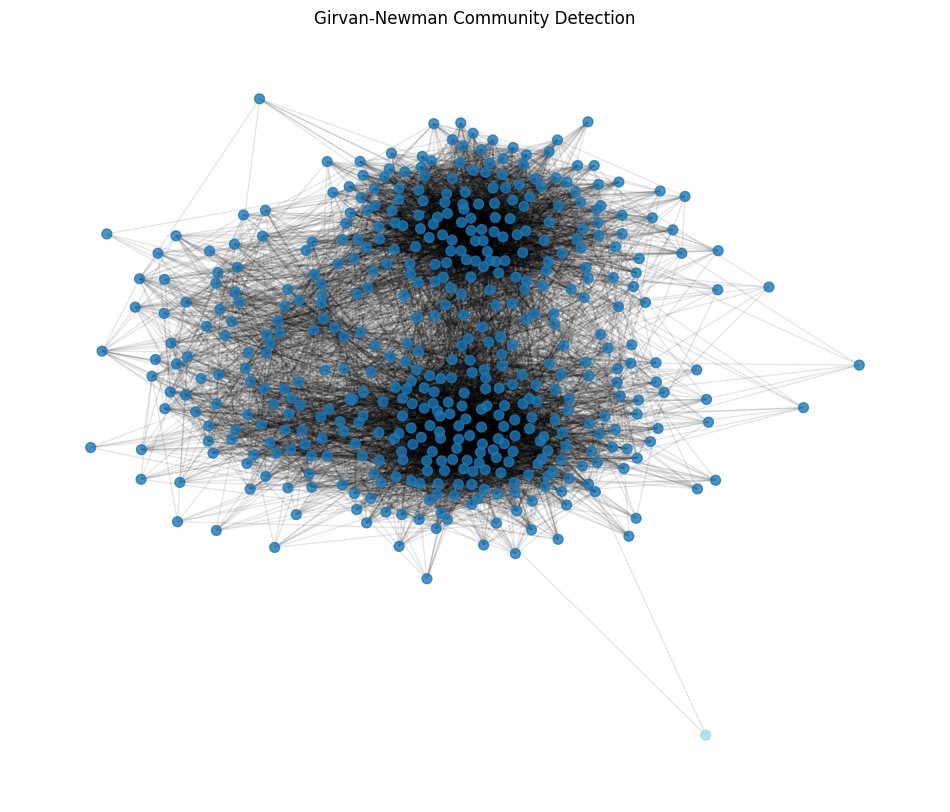

In [25]:


# Apply Girvan-Newman algorithm
communities_generator = co.girvan_newman(G)

# Iterate to get a suitable partition (e.g., the first non-trivial partition)
# For larger graphs, iterating until modularity peaks or a certain number of communities is reached might be better.
# For this example, let's take the first partition found by the generator.

# Get the first partition
# The generator yields a tuple of frozensets, each frozenset is a community
# We'll take the first split (2 communities)

try:
    # Get communities for the first split
    first_partition = next(communities_generator)
    # Convert frozensets to sets for easier manipulation if needed
    communities = [set(c) for c in first_partition]

    # If the first split is trivial (e.g., one huge community and many singletons), try to get the next split
    # However, for Girvan-Newman, it typically starts by splitting the graph into two large components.
    # For simplicity, we stick to the first partition initially.

    print(f"Initial number of communities found: {len(communities)}")

    # Calculate modularity
    mod = co.modularity(G, communities)

    # Determine number of communities
    num_communities = len(communities)

    # Calculate size distribution
    community_sizes = [len(c) for c in communities]

    print(f"\n--- Girvan-Newman Community Detection ---")
    print(f"Number of communities: {num_communities}")
    print(f"Community size distribution (first 10, sorted): {sorted(community_sizes, reverse=True)[:10]}")
    print(f"Modularity: {mod:.4f}")

    # Create a mapping from node to color based on community
    node_colors = ['None'] * G.number_of_nodes() # Initialize with 'None' or a default color
    color_map = plt.cm.get_cmap('tab20', num_communities)

    node_to_community_id = {}
    for i, comm in enumerate(communities):
        for node in comm:
            node_to_community_id[node] = i

    # Assign colors based on community ID
    # Ensure all nodes in G are covered. Some nodes might be isolated and not part of any found community if `first_partition` is not exhaustive.
    # The Girvan-Newman typically provides a partition of all nodes.

    colors = [color_map(node_to_community_id.get(node, -1)) for node in G.nodes()]

    # Visualize the communities
    plt.figure(figsize=(12, 10))
    pos = nx.spring_layout(G, k=0.1, iterations=50) # Fruchterman-Reingold layout for better visualization
    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=50, alpha=0.8)
    nx.draw_networkx_edges(G, pos, alpha=0.1)
    plt.title("Girvan-Newman Community Detection")
    plt.axis('off')
    plt.show()

except StopIteration:
    print("Girvan-Newman generator did not yield any communities.")
except Exception as e:
    print(f"An error occurred: {e}")



--- Label Propagation Community Detection ---
Number of communities: 2
Community size distribution (first 10, sorted): [307, 168]
Modularity: 0.3333


/tmp/ipython-input-2104530564.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('tab20', num_communities)


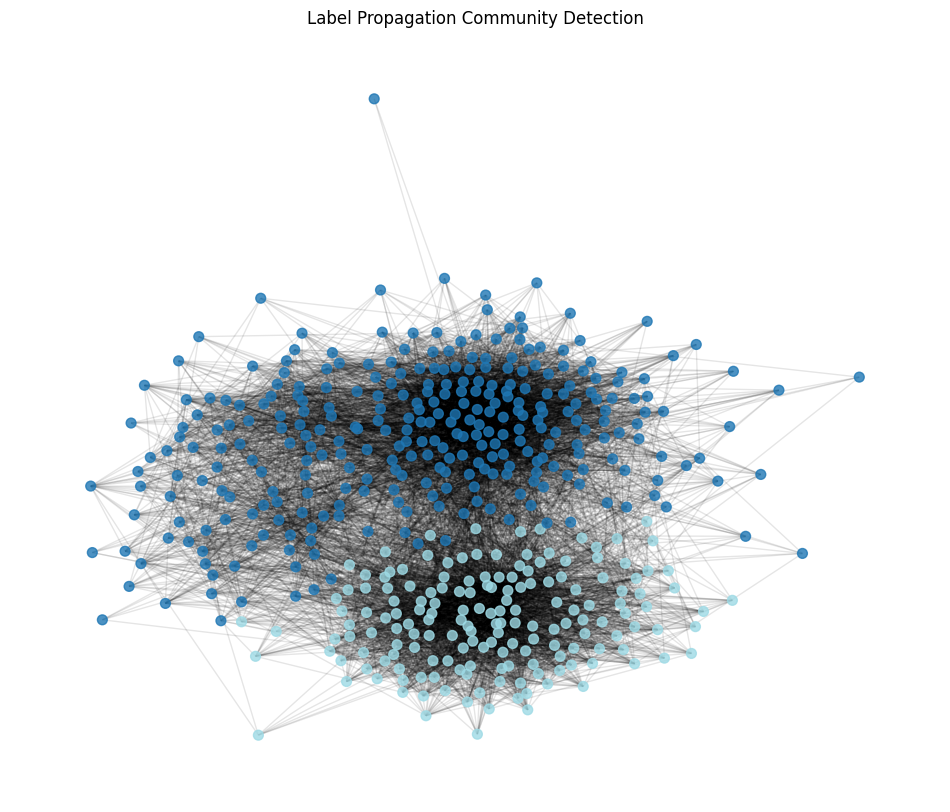

In [27]:


print("\n--- Label Propagation Community Detection ---")

# Apply Label Propagation algorithm
# This function returns an iterator of frozensets, each representing a community.
communities_lp = list(co.label_propagation_communities(G))

# Convert frozensets to sets for easier manipulation
communities = [set(c) for c in communities_lp]

# Determine number of communities
num_communities = len(communities)

# Calculate size distribution
community_sizes = [len(c) for c in communities]

# Calculate modularity
mod = co.modularity(G, communities)

print(f"Number of communities: {num_communities}")
print(f"Community size distribution (first 10, sorted): {sorted(community_sizes, reverse=True)[:10]}")
print(f"Modularity: {mod:.4f}")

# Create a mapping from node to color based on community
node_to_community_id = {}
for i, comm in enumerate(communities):
    for node in comm:
        node_to_community_id[node] = i

# Get a colormap, ensuring it can handle the number of communities
color_map = plt.cm.get_cmap('tab20', num_communities)

# Assign colors based on community ID
colors = [color_map(node_to_community_id.get(node, -1)) for node in G.nodes()]

# Visualize the communities
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, k=0.1, iterations=50) # Fruchterman-Reingold layout
nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=50, alpha=0.8)
nx.draw_networkx_edges(G, pos, alpha=0.1)
plt.title("Label Propagation Community Detection")
plt.axis('off')
plt.show()


We see that we have gotten drastically differing results with these two algorithms.  While both have two communities, GN gave us a singleton in its own community.  I believe the Label Propogation to have given us the best result.


## Part 2 — Partition Quality Metrics (15%)
Compute ≥3 metrics across partitions: **Modularity, Conductance, Coverage/Performance, Normalized Cut**.

**Outputs:** comparison table + commentary on trade-offs.


In [ ]:

# TODO: Implement metrics and build comparison table
# TODO: Commentary (markdown)



## Part 3 — Resolution & Sensitivity (15%)
Pick one axis (seeds/resolution/subsampling). Produce agreement curves (NMI/VI) or #communities/modularity vs parameter.

**Outputs:** plot(s) + short explanation.


In [ ]:

# TODO: Implement chosen sensitivity experiment and plot



## Part 4 — Overlapping Communities (10%)
Run **k-clique percolation** (`nx.algorithms.community.k_clique_communities`).

**Outputs:** k choice + justification, #communities, overlap examples, avg membership per node, size distribution, brief comparison to non-overlapping partition.


In [ ]:

# TODO: Run k-clique percolation and summarize overlaps



## Part 5 — Benchmarking with Planted Communities (20%)
Generate **SBM** (or LFR) with ground-truth communities. Run ≥2 algorithms; evaluate with **NMI/ARI**. Optionally vary inter-block probability and plot accuracy vs difficulty.


In [ ]:

# TODO: Build SBM/LFR; run algorithms; compute NMI/ARI; (optional) sweep difficulty



## Part 6 — Community Roles (10%)
Compute **within-module z-score (zᵢ)** and **participation coefficient (Pᵢ)** for a chosen partition.

**Outputs:** scatter of P vs z + brief role interpretation (e.g., provincial hubs, connectors).


In [ ]:

# TODO: Compute z and P; scatter plot; role notes



## Part 7 — Mini Write-up (2–3 pages) (10%)
Synthesize findings; cite datasets and optional packages; discuss limitations (stochasticity, parameter choices, scalability).



## Rubric (100 pts)
- Part 1 Baseline Methods — **20**
- Part 2 Quality Metrics — **15**
- Part 3 Sensitivity/Resolution — **15**
- Part 4 Overlapping Communities — **10**
- Part 5 Benchmark (SBM/LFR) — **20**
- Part 6 Roles (z & P) — **10**
- Part 7 Write-up — **10**

**Integrity & Reproducibility:** student-written code; runnable notebook; include **LLM Usage Log** below.


## LLM Usage Log

1. implement the following community detection models: Girvan-Newman, Label Propogation, Louvain, and spectral clustering on my graph G

In [ ]:
# TODO: Paste 2–3 prompts and note what you accepted vs modified.
